# Regresion Lineal Multiple - Gasto extra en gimnasio
---

**Autor:** Borja Mora Mendez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoria:** Machine Learning · Supervisado · Regresion · Regresion Lineal Multiple

---

### Objetivo

Predecir el **gasto mensual extra** de un cliente de gimnasio (suplementos, clases premium, merchandising) a partir de su antiguedad, asistencias y uso en horas pico. El mismo dataset del gimnasio que se usa en clasificacion — aqui con una pregunta de regresion.

### Conexion con el portfolio

Este es el dataset transversal del portfolio. En [clasificacion](../../../clasificacion/) se predice `Satisfecho` y `Abandono`. Aqui se predice `Gasto_Mensual_Extra` — la misma base de datos, tres angulos de analisis distintos.

### Contexto de negocio

**El cliente:** la cadena de gimnasios quiere aumentar el revenue por socio sin subir cuotas.

**El problema:** algunos clientes gastan mucho en extras (PT, suplementos, clases) y otros nada. El equipo de marketing necesita identificar los drivers del gasto para disenar ofertas personalizadas.

**La pregunta:** que variables operativas predicen cuanto gastara un cliente en extras?

## 2. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from scipy import stats

pd.set_option("display.max_columns", None)

# Estilo visual — sistema de color validado (consejo UX/UI Data)
BACKGROUND    = '#fbfbfb'
PURPLE        = '#7a7bff'   # único color de énfasis (1 por gráfico) / serie única en scatter y líneas
PURPLE_LIGHT  = '#9b9cff'   # EDA de una sola serie (histogramas) -- PURPLE fuerte queda solo para el enfasis
POSITIVE      = '#6b8158'   # exclusivo signo positivo
NEGATIVE      = '#c34031'   # exclusivo signo negativo
NEUTRAL_BAR   = '#d9d9d9'   # barras/áreas de contexto (siempre con etiqueta de valor)
NEUTRAL_LINE  = '#8f8c9e'   # líneas de contexto (más contraste que NEUTRAL_BAR)
CONTEXT_LINES = [NEUTRAL_LINE, '#a89a8a', '#7d94a8']   # gama fija para 2+ líneas de contexto en un mismo gráfico
INK           = '#111111'
MUTED         = '#707070'

DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "borja_diverging", ["#c34031", "#e0a89f", "#f0ede8", "#b7c2a9", "#6b8158"]
)
SEQUENTIAL_GREEN = LinearSegmentedColormap.from_list(
    "borja_sequential", [BACKGROUND, POSITIVE]
)

def color_annotations(ax, values, threshold, dark="#ffffff", light=INK):
    """Recolorea el texto de un heatmap celda a celda según su magnitud."""
    for text, value in zip(ax.texts, np.asarray(values).flatten()):
        text.set_color(dark if abs(value) >= threshold else light)

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'figure.facecolor': BACKGROUND,
    'axes.facecolor': BACKGROUND,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})

## 3. Carga y exploracion inicial

In [2]:
data = pd.read_excel("gym_clientes.xlsx")
print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()

Registros: 300 | Columnas: 7


,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
0,1,29,1,8.673509,64.161055,0,1
1,2,15,1,4.396600,32.554177,0,0
2,3,8,22,22.313433,85.092643,1,0
3,4,21,21,20.598791,120.709423,1,0
4,5,19,18,18.783644,103.148141,1,0


In [3]:
data.describe().round(2)

,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
count,300.00,300.00,300.00,300.00,300.00,300.00,300.00
mean,150.50,18.88,12.16,14.67,81.69,0.48,0.16
std,86.75,10.60,7.27,6.09,30.47,0.50,0.37
min,1.00,1.00,0.00,1.41,10.00,0.00,0.00
25%,75.75,9.00,6.00,9.65,61.25,0.00,0.00
50%,150.50,20.00,12.00,15.07,82.24,0.00,0.00
75%,225.25,28.00,18.25,19.75,104.11,1.00,0.00
max,300.00,35.00,24.00,24.00,145.91,1.00,1.00


In [4]:
print("Valores nulos:")
print(data.isnull().sum().to_string())
print(f"\nDuplicados: {data.duplicated(subset=[c for c in data.columns if c != 'ID_Cliente']).sum()}")

Valores nulos:
ID_Cliente             0
Antiguedad_Meses       0
Asistencias_Mes        0
Horas_Pico_Mes         0
Gasto_Mensual_Extra    0
Satisfecho             0
Abandono               0

Duplicados: 0


## 4. Analisis exploratorio

**Variables candidatas:** Antiguedad_Meses, Asistencias_Mes, Horas_Pico_Mes.
**Target:** Gasto_Mensual_Extra.

Se excluyen `Satisfecho` y `Abandono` porque son targets de clasificacion (usarlos como features para predecir gasto crearia circularidad logica en el contexto de negocio).

Las tres variables se exploran aqui como candidatas. La matriz de correlacion (mas abajo) ya deja ver una senal relevante para la seleccion final de predictores en la Seccion 5.

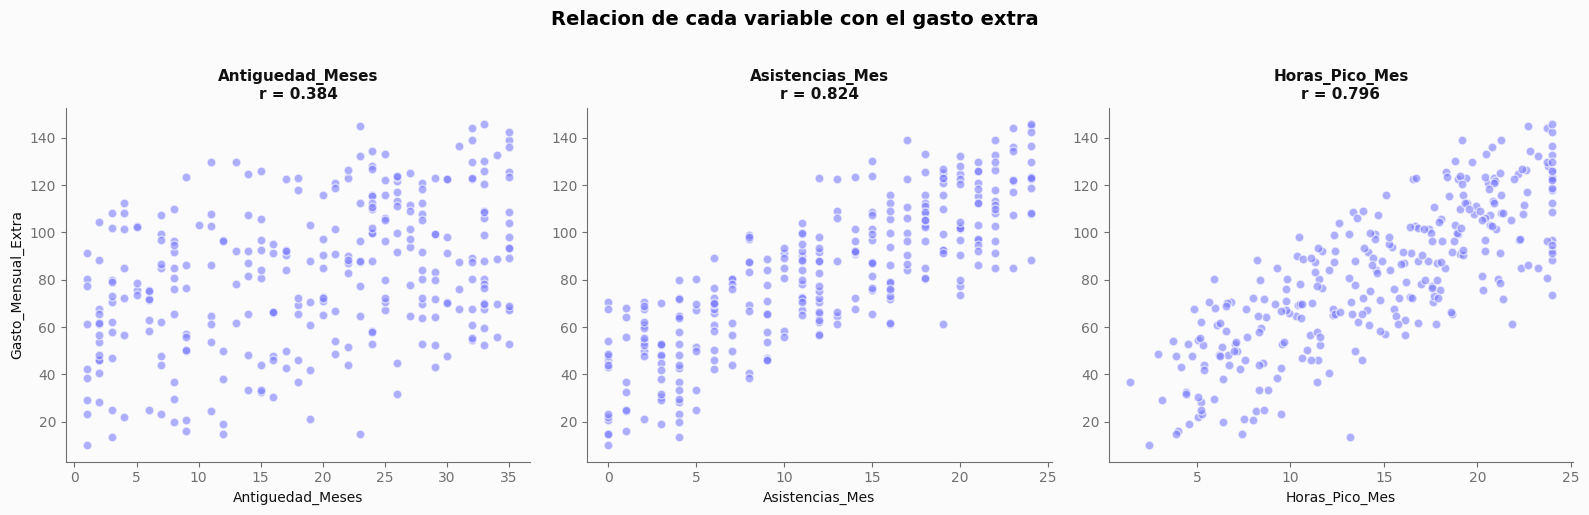

In [5]:
features = ["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes"]
target = "Gasto_Mensual_Extra"

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(features):
    axes[i].scatter(data[col], data[target], color=PURPLE, alpha=0.6, edgecolors="white", s=40)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel(target if i == 0 else "")
    r = data[col].corr(data[target])
    axes[i].set_title(f"{col}\nr = {r:.3f}", fontsize=11, fontweight="bold")

plt.suptitle("Relacion de cada variable con el gasto extra", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

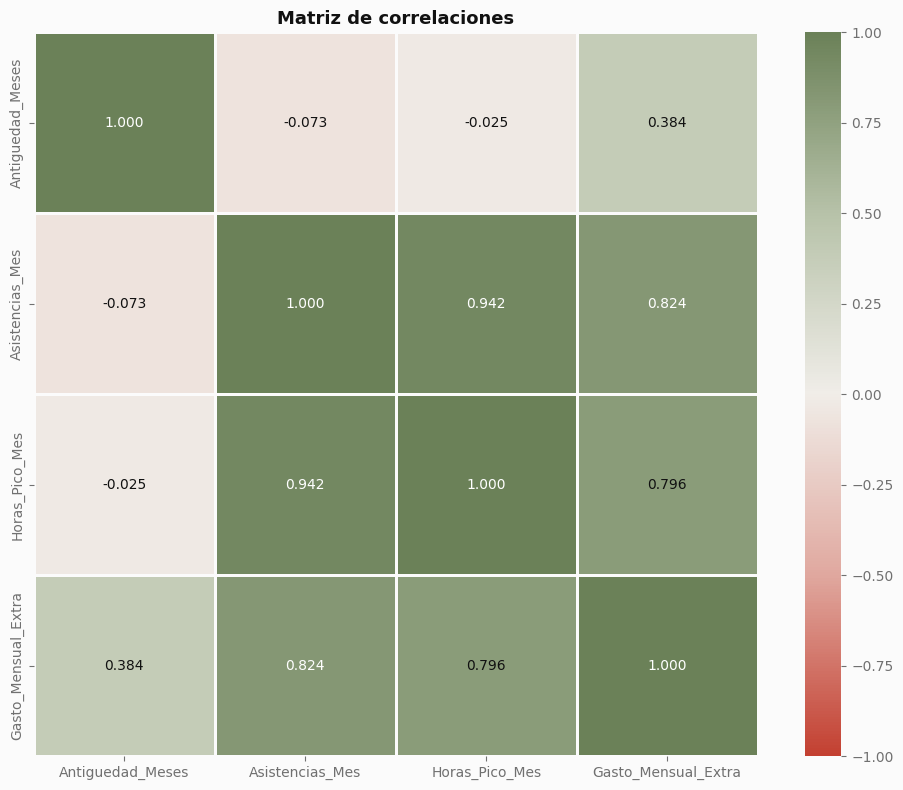

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = data[features + [target]].corr()
sns.heatmap(corr_matrix, annot=True, cmap=DIVERGING_CMAP, center=0, vmin=-1, vmax=1, fmt=".3f",
            square=True, linewidths=2, linecolor=BACKGROUND, ax=ax)
color_annotations(ax, corr_matrix.values, threshold=0.8)
ax.set_title("Matriz de correlaciones", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Preparacion de datos

**Seleccion de predictores para el modelo final:** se excluye `Horas_Pico_Mes`. La matriz de correlacion de la Seccion 4 ya muestra r ~ 0.94 entre `Horas_Pico_Mes` y `Asistencias_Mes` — practicamente la misma informacion. Incluir ambas infla la varianza de los coeficientes (VIF severo) sin aportar poder predictivo real, y en un ajuste previo con las tres variables `Horas_Pico_Mes` no resulto significativa (p = 0.940). El modelo final usa `Antiguedad_Meses` y `Asistencias_Mes`, manteniendo el mismo `random_state` y `test_size` que el resto del pipeline.

In [ ]:
features = ["Antiguedad_Meses", "Asistencias_Mes"]  # Horas_Pico_Mes excluida (ver Seccion 5)
X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

## 6. Modelo con statsmodels — inferencia

In [ ]:
# Modelo final (Antiguedad_Meses, Asistencias_Mes) — ver Seccion 5
X_train_const = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_const).fit()
print(ols_model.summary())

## 7. Diagnostico de multicolinealidad (VIF)

In [ ]:
# VIF sobre el modelo final (2 predictores) — deberia bajar mucho al quitar Horas_Pico_Mes
vif_data = pd.DataFrame({
    "Variable": features,
    "VIF": [variance_inflation_factor(X_train.values, i) for i in range(len(features))]
})
vif_data["Diagnostico"] = vif_data["VIF"].apply(
    lambda x: "OK" if x < 5 else ("Moderado" if x < 10 else "Problematico")
)
print("VIF:")
print(vif_data.to_string(index=False))

## 8. Modelo con sklearn — prediccion y metricas

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Ecuacion:")
print(f"  Gasto_Extra = {model.intercept_:.4f}", end="")
for name, coef in zip(features, model.coef_):
    sign = "+" if coef >= 0 else ""
    print(f" {sign} {coef:.4f}*{name}", end="")
print()

In [ ]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
r2_adj = 1 - (1-r2) * (len(y_test)-1) / (len(y_test)-len(features)-1)

print("Metricas:")
print(f"  MAE:    {mae:.2f} EUR")
print(f"  RMSE:   {rmse:.2f} EUR")
print(f"  R2:     {r2:.4f} ({r2:.1%})")
print(f"  R2 adj: {r2_adj:.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, color=PURPLE, alpha=0.6, edgecolors="white", s=40)
lims = [min(y_test.min(), y_pred.min())-5, max(y_test.max(), y_pred.max())+5]
axes[0].plot(lims, lims, color=INK, linestyle="--", linewidth=1, label="Prediccion perfecta")
axes[0].set_xlabel("Gasto real", fontsize=11)
axes[0].set_ylabel("Gasto predicho", fontsize=11)
axes[0].set_title(f"Real vs Predicho (R2={r2:.3f})", fontsize=12, fontweight="bold")
axes[0].legend()

coef_df = pd.DataFrame({"Variable": features, "Coeficiente": model.coef_}).sort_values("Coeficiente")
colors = [POSITIVE if c > 0 else NEGATIVE for c in coef_df["Coeficiente"]]
axes[1].barh(coef_df["Variable"], coef_df["Coeficiente"], color=colors, edgecolor="white")
axes[1].set_xlabel("Coeficiente", fontsize=11)
axes[1].set_title("Impacto de cada variable", fontsize=12, fontweight="bold")
axes[1].axvline(0, color=INK, linewidth=0.5)

plt.tight_layout()
plt.show()

## 9. Diagnostico de supuestos

In [ ]:
residuos = y_test - y_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].scatter(y_pred, residuos, color=PURPLE, alpha=0.5, edgecolors="white", s=40)
axes[0,0].axhline(0, color=INK, linewidth=1.5, linestyle="--")
axes[0,0].set_title("1. Linealidad", fontsize=11, fontweight="bold")

stats.probplot(residuos, dist="norm", plot=axes[0,1])
axes[0,1].get_lines()[0].set_markerfacecolor(PURPLE)
axes[0,1].get_lines()[0].set_markeredgecolor("white")
axes[0,1].get_lines()[0].set_color(PURPLE)
axes[0,1].get_lines()[1].set_color(INK)
axes[0,1].set_title("2. Normalidad — QQ Plot", fontsize=11, fontweight="bold")

axes[1,0].scatter(y_pred, np.abs(residuos), color=PURPLE, alpha=0.5, edgecolors="white", s=40)
axes[1,0].set_title("3. Homocedasticidad", fontsize=11, fontweight="bold")

bias_color = POSITIVE if residuos.mean() >= 0 else NEGATIVE
axes[1,1].hist(residuos, bins=15, color=PURPLE, edgecolor="white", alpha=0.85)
axes[1,1].axvline(0, color=INK, linestyle="--", linewidth=1.5)
axes[1,1].axvline(residuos.mean(), color=bias_color, linestyle="--", linewidth=1.5, label=f"Sesgo medio: {residuos.mean():.2f}")
axes[1,1].set_title("4. Distribucion de residuos", fontsize=11, fontweight="bold")
axes[1,1].legend(frameon=False, fontsize=9)

plt.suptitle("Diagnostico de supuestos", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

stat, p = stats.shapiro(residuos)
print(f"Shapiro-Wilk: W={stat:.4f}, p={p:.4f}")
print(f"  {'Residuos normales (p > 0.05)' if p > 0.05 else 'Residuos NO normales (p <= 0.05)'}")

## 10. Insights de negocio y recomendaciones

### El hallazgo

> El gasto extra esta impulsado por la **antiguedad** y la **asistencia mensual**, las dos variables del modelo final (ambas con p < 0.001 en el modelo OLS: coeficientes 1.326 y 3.527 respectivamente, R² = 0.888 en train). `Horas_Pico_Mes` se excluyo del modelo: en un ajuste previo con las tres variables no resulto significativa (p = 0.940) y presentaba una multicolinealidad severa con `Asistencias_Mes` (VIF ~ 40 y 30 respectivamente, correlacion r ~ 0.94 entre ambas) — es decir, media practicamente lo mismo que la asistencia sin aportar informacion independiente sobre el gasto. Tras eliminarla, el VIF de las dos variables restantes cae a ~1.00 (sin rastro de colinealidad) y el poder predictivo se mantiene intacto: R² en test = 0.840, MAE = 9.58 EUR, RMSE = 11.75 EUR — identico al modelo con las tres variables, confirmando que `Horas_Pico_Mes` no aportaba capacidad predictiva real.

### Ecuacion del modelo final

`Gasto_Extra = 13.66 + 1.326 * Antiguedad_Meses + 3.527 * Asistencias_Mes`

Por cada mes adicional de antiguedad, el gasto extra estimado aumenta 1.33 EUR (manteniendo constante la asistencia); por cada asistencia adicional al mes, aumenta 3.53 EUR (manteniendo constante la antiguedad).

### Recomendaciones

**1. Segmentar ofertas por perfil de uso (impacto: alto)**
Los clientes con alta asistencia y alta antiguedad son los mejores candidatos para upselling de servicios premium (PT personal, nutricion, clases exclusivas).

**2. Incentivar asistencia para aumentar gasto (impacto: medio)**
La asistencia es el driver con mayor peso relativo en el modelo (coeficiente mas alto y VIF ~1.00, sin distorsion por colinealidad). Programas de fidelizacion que aumenten las visitas (retos mensuales, streaks) pueden tener un efecto directo y medible en el revenue por extras.

**3. Modelo simplificado (completado)**
Se reentreno el modelo excluyendo `Horas_Pico_Mes` por su severa colinealidad con `Asistencias_Mes`. El modelo final usa dos predictores (`Antiguedad_Meses`, `Asistencias_Mes`), es mas simple de interpretar y de operar (una variable menos que monitorizar) y no pierde capacidad predictiva frente al modelo con las tres variables originales.

**4. Conexion con retencion (impacto: portfolio)**
Este mismo dataset se usa para predecir [abandono (regresion logistica)](../../../clasificacion/05-regresion-logistica/01-gimnasio/) y [satisfaccion (arboles)](../../../clasificacion/01-arbol-decision/). Los tres analisis juntos dan una vision 360 del cliente.